# Water Potability — Exploratory Data Analysis

**Goal:** Predict whether a water sample is safe to drink.

**Why recall, not accuracy:** A false negative means the model calls unsafe water safe and someone drinks it. A false positive just flags a safe sample unnecessarily. The costs aren't symmetric, so recall is the metric that matters.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = '/kaggle/input/datasets/adityakadiwal/water-potability/water_potability.csv'
df = pd.read_csv(path)

In [2]:
print("Shape:", df.shape)
print()
print(df.head())

Shape: (3276, 10)

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


## Dataset Structure

3,276 samples, 9 feature columns plus the target `Potability`. All features are numeric measurements of water chemistry — no categorical encoding needed.

In [3]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


## Summary Statistics

Feature scales vary widely — `Solids` runs to ~61,000 while `Turbidity` stays under 7. Not an issue for tree-based models, but it would matter for anything distance-based.

**Worth flagging:** `ph` spans exactly 0.00 to 14.00 — the full theoretical pH scale. Real water samples don't reach either endpoint, which suggests the data is synthetic or clipped. Reason to be cautious about how much any model trained on it says about actual water.

In [4]:
print("Missing counts:")
print(df.isnull().sum())
print()
print("Missing %:")
print((df.isnull().sum() / len(df) * 100).round(2))
print()
print("Rows with any missing:", df.isnull().any(axis=1).sum())
print("Fully complete rows:", df.dropna().shape[0])

Missing counts:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Missing %:
ph                 14.99
Hardness            0.00
Solids              0.00
Chloramines         0.00
Sulfate            23.84
Conductivity        0.00
Organic_carbon      0.00
Trihalomethanes     4.95
Turbidity           0.00
Potability          0.00
dtype: float64

Rows with any missing: 1265
Fully complete rows: 2011


## Missing Values

| Column | Missing | % |
|---|---|---|
| Sulfate | 781 | 23.84% |
| ph | 491 | 14.99% |
| Trihalomethanes | 162 | 4.95% |

All other columns are complete.

1,434 missing cells spread across **1,265 rows** — so ~169 rows are missing more than one value. **2,011 rows are fully complete.**

Dropping incomplete rows would leave 2,011 samples, which is workable. Imputing keeps all 3,276. Going with imputation, but the drop option is viable enough to compare against later if imputation seems to be hurting.

In [5]:
for col in ['ph', 'Sulfate', 'Trihalomethanes']:
    print(f"{col}: mean={df[col].mean():.2f}, median={df[col].median():.2f}, skew={df[col].skew():.2f}")

ph: mean=7.08, median=7.04, skew=0.03
Sulfate: mean=333.78, median=333.07, skew=-0.04
Trihalomethanes: mean=66.40, median=66.62, skew=-0.08


## Imputation Strategy

Checking whether median is actually justified over mean:

| Column | Mean | Median | Skew |
|---|---|---|---|
| ph | 7.08 | 7.04 | 0.03 |
| Sulfate | 333.78 | 333.07 | -0.04 |
| Trihalomethanes | 66.40 | 66.62 | -0.08 |

All three are near-symmetric (|skew| < 0.1) and mean/median differ negligibly. **Mean and median imputation would give nearly identical results here.** Median is chosen as the safer default against outliers, not because these distributions require it.

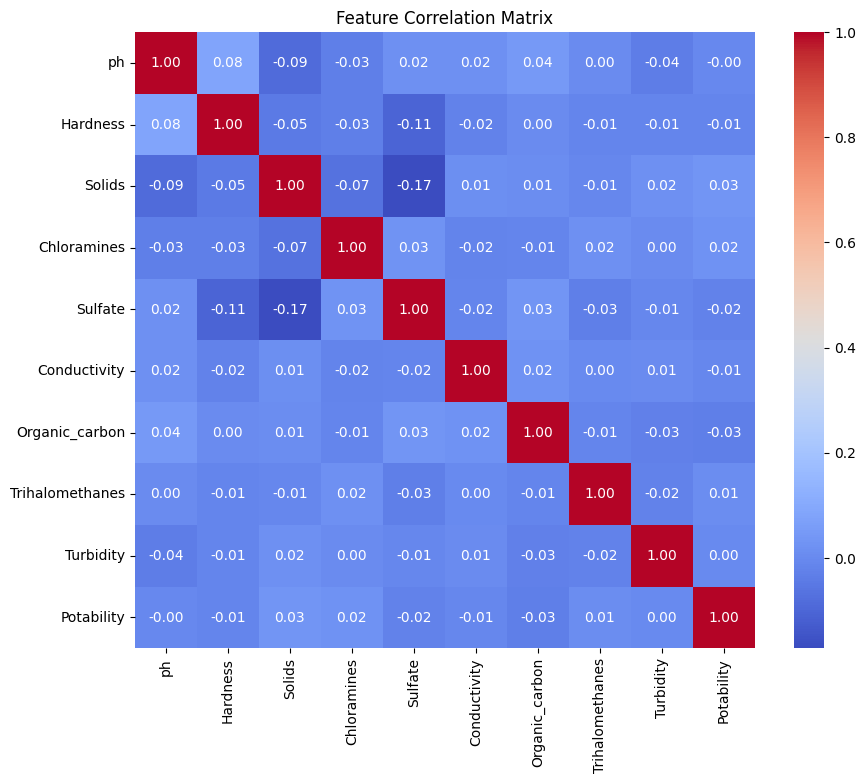

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## Correlation

Every value falls between -0.17 and 0.08. No feature has a meaningful linear relationship with `Potability` (all |r| < 0.05). Strongest pair anywhere: Sulfate–Solids at -0.17.

This is a real finding, not a failed analysis. Any predictive signal here is non-linear, which rules out plain logistic regression and supports tree-based models that capture feature interactions.

**Caveat:** `.corr()` uses pairwise deletion, so each cell is computed on a slightly different row subset depending on which columns have NaNs. Worth re-checking post-imputation.

Potability
0    1998
1    1278
Name: count, dtype: int64

Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


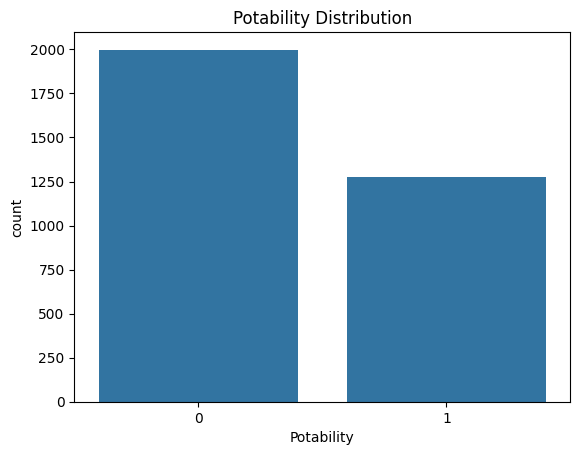

In [7]:
print(df['Potability'].value_counts())
print()
print(df['Potability'].value_counts(normalize=True).round(3))

sns.countplot(x='Potability', data=df)
plt.title('Potability Distribution')
plt.show()

## Class Balance

1,998 not potable (61%) vs 1,278 potable (39%). Imbalanced, but 1,278 minority samples is enough to train on without resampling.

**61% is the accuracy floor** — a model that always predicts "not potable" scores that while learning nothing. Any baseline must be measured against it.